In [1]:
import numpy as np
from sklearn.cluster import DBSCAN

# -------------------------------
# SAMPLE DATA (simple points)
# -------------------------------
X = np.array([
    [1, 2], [2, 2], [2, 3],      # cluster 1
    [8, 7], [8, 8], [7, 7],      # cluster 2
    [25, 80]                     # noise point
])

# Run DBSCAN
db = DBSCAN(eps=1.9, min_samples=2).fit(X)
labels = db.labels_

print("Labels:", labels)  # -1 = noise

# CORE SAMPLES
core_samples = db.core_sample_indices_
print("Core sample indices:", core_samples)

# NOISE POINTS
noise_points = np.where(labels == -1)[0]
print("Noise points:", noise_points)

# BORDER POINTS
border_points = [i for i in range(len(X)) if labels[i] != -1 and i not in core_samples]
print("Border points:", border_points)


Labels: [ 0  0  0  1  1  1 -1]
Core sample indices: [0 1 2 3 4 5]
Noise points: [6]
Border points: []


Clusters: 2
Noise: 0


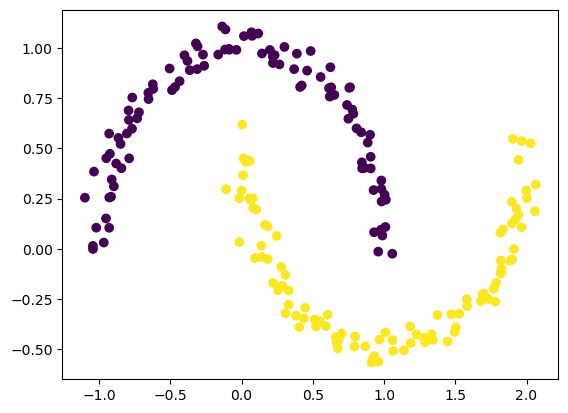

In [2]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, _ = make_moons(200, noise=0.05, random_state=42)
labels = DBSCAN(eps=0.3, min_samples=5).fit_predict(X)

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise:", list(labels).count(-1))

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.show()